This classifier should only classify  the slices where a pathology can be seen.

In [3]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import timm
import pickle

DATA_PATH = "D:/ML/RSNA2024"

In [4]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Data Processing

In [5]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df = df.fillna("Normal/Mild")
df.set_index("study_id", inplace=True)
df.head(10)

,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,left_neural_foraminal_narrowing_l5_s1,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
study_id,,,,,,,,,,,,,,,,,,,,,
4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild
11340341,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild
11943292,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
13317052,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Severe,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate
22191399,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Moderate


In [6]:
pd.unique(df["spinal_canal_stenosis_l1_l2"])

array(['Normal/Mild', 'Moderate', 'Severe'], dtype=object)

In [7]:
dfDescr = pd.read_csv(os.path.join(DATA_PATH, "train_series_descriptions.csv"))
uniqueSeriesDescr = dfDescr["series_description"].unique()
dfDescr.set_index(["study_id", "series_description"], inplace=True)
dfDescr.sort_index(inplace=True)
dfDescr.head(25)

series_id
study_id series_description            
4003253  Axial T2            2448190387
         Sagittal T1         1054713880
         Sagittal T2/STIR     702807833
4646740  Axial T2            3201256954
         Sagittal T1         3486248476
         Sagittal T2/STIR    3666319702
7143189  Axial T2            1951927562
         Sagittal T1         3219733239
         Sagittal T2/STIR     132939515
8785691  Axial T2            2406919186
         Sagittal T1         1570286759
         Sagittal T2/STIR     481125819
10728036 Axial T2             142859125
         Axial T2            2073726394
         Sagittal T1         2399638375
         Sagittal T2/STIR    3491739931
11340341 Axial T2            1224932122
         Sagittal T1         2231042680
         Sagittal T2/STIR    3543553307
11943292 Axial T2             403244853
         Axial T2            3800798510
         Sagittal T1         1212326388
         Sagittal T2/STIR    1638921810
13317052 Axial T2            2500166693
         Sagittal T1         1539051863

In [8]:
dfCoord = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))
dfCoord.set_index(["study_id", "series_id"], inplace=True)
dfCoord.head(20)

instance_number                         condition  level  \
study_id series_id                                                              
4003253  702807833                 8             Spinal Canal Stenosis  L1/L2   
         702807833                 8             Spinal Canal Stenosis  L2/L3   
         702807833                 8             Spinal Canal Stenosis  L3/L4   
         702807833                 8             Spinal Canal Stenosis  L4/L5   
         702807833                 8             Spinal Canal Stenosis  L5/S1   
         1054713880                4  Right Neural Foraminal Narrowing  L4/L5   
         1054713880                4  Right Neural Foraminal Narrowing  L5/S1   
         1054713880                5  Right Neural Foraminal Narrowing  L3/L4   
         1054713880                6  Right Neural Foraminal Narrowing  L1/L2   
         1054713880                6  Right Neural Foraminal Narrowing  L2/L3   
         1054713880               11   Left Neural Foraminal Narrowing  L1/L2   
         1054713880               11   Left Neural Foraminal Narrowing  L4/L5   
         1054713880               11   Left Neural Foraminal Narrowing  L5/S1   
         1054713880               12   Left Neural Foraminal Narrowing  L2/L3   
         1054713880               12   Left Neural Foraminal Narrowing  L3/L4   
         2448190387                3        Left Subarticular Stenosis  L1/L2   
         2448190387                4       Right Subarticular Stenosis  L1/L2   
         2448190387               11        Left Subarticular Stenosis  L2/L3   
         2448190387               11       Right Subarticular Stenosis  L2/L3   
         2448190387               19        Left Subarticular Stenosis  L3/L4   

                              x           y  
study_id series_id                           
4003253  702807833   322.831858  227.964602  
         702807833   320.571429  295.714286  
         702807833   323.030303  371.818182  
         702807833   335.292035  427.327434  
         702807833   353.415929  483.964602  
         1054713880  187.961759  251.839388  
         1054713880  198.240918  285.613767  
         1054713880  187.227533  210.722753  
         1054713880  194.569790  127.755258  
         1054713880  191.632887  165.934990  
         1054713880  196.070671  126.021201  
         1054713880  186.504472  251.592129  
         1054713880  197.100569  289.457306  
         1054713880  191.321555  170.120141  
         1054713880  187.878354  217.245081  
         2448190387  179.126448  161.235521  
         2448190387  145.288771  158.624642  
         2448190387  180.979730  158.764479  
         2448190387  145.900042  157.096466  
         2448190387  176.037645  157.528958

In [9]:
dfCoordIdx = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))
dfCoordIdx.set_index(["study_id", "series_id", "instance_number"], inplace=True)
uniqueStudSerInst = dfCoordIdx.index.unique()
uniqueStudSerInst

MultiIndex([(   4003253,  702807833,  8),
            (   4003253, 1054713880,  4),
            (   4003253, 1054713880,  5),
            (   4003253, 1054713880,  6),
            (   4003253, 1054713880, 11),
            (   4003253, 1054713880, 12),
            (   4003253, 2448190387,  3),
            (   4003253, 2448190387,  4),
            (   4003253, 2448190387, 11),
            (   4003253, 2448190387, 19),
            ...
            (4290709089, 3390218084,  5),
            (4290709089, 3390218084,  6),
            (4290709089, 3390218084, 10),
            (4290709089, 3390218084, 15),
            (4290709089, 3390218084, 20),
            (4290709089, 3390218084, 21),
            (4290709089, 4237840455,  4),
            (4290709089, 4237840455,  5),
            (4290709089, 4237840455, 11),
            (4290709089, 4237840455, 12)],
           names=['study_id', 'series_id', 'instance_number'], length=24546)

In [10]:
dfCoordIdx.head(20)

condition  level  \
study_id series_id  instance_number                                            
4003253  702807833  8                           Spinal Canal Stenosis  L1/L2   
                    8                           Spinal Canal Stenosis  L2/L3   
                    8                           Spinal Canal Stenosis  L3/L4   
                    8                           Spinal Canal Stenosis  L4/L5   
                    8                           Spinal Canal Stenosis  L5/S1   
         1054713880 4                Right Neural Foraminal Narrowing  L4/L5   
                    4                Right Neural Foraminal Narrowing  L5/S1   
                    5                Right Neural Foraminal Narrowing  L3/L4   
                    6                Right Neural Foraminal Narrowing  L1/L2   
                    6                Right Neural Foraminal Narrowing  L2/L3   
                    11                Left Neural Foraminal Narrowing  L1/L2   
                    11                Left Neural Foraminal Narrowing  L4/L5   
                    11                Left Neural Foraminal Narrowing  L5/S1   
                    12                Left Neural Foraminal Narrowing  L2/L3   
                    12                Left Neural Foraminal Narrowing  L3/L4   
         2448190387 3                      Left Subarticular Stenosis  L1/L2   
                    4                     Right Subarticular Stenosis  L1/L2   
                    11                     Left Subarticular Stenosis  L2/L3   
                    11                    Right Subarticular Stenosis  L2/L3   
                    19                     Left Subarticular Stenosis  L3/L4   

                                              x           y  
study_id series_id  instance_number                          
4003253  702807833  8                322.831858  227.964602  
                    8                320.571429  295.714286  
                    8                323.030303  371.818182  
                    8                335.292035  427.327434  
                    8                353.415929  483.964602  
         1054713880 4                187.961759  251.839388  
                    4                198.240918  285.613767  
                    5                187.227533  210.722753  
                    6                194.569790  127.755258  
                    6                191.632887  165.934990  
                    11               196.070671  126.021201  
                    11               186.504472  251.592129  
                    11               197.100569  289.457306  
                    12               191.321555  170.120141  
                    12               187.878354  217.245081  
         2448190387 3                179.126448  161.235521  
                    4                145.288771  158.624642  
                    11               180.979730  158.764479  
                    11               145.900042  157.096466  
                    19               176.037645  157.528958

In [11]:
allConditions = pd.unique(dfCoord["condition"])
allLevels = pd.unique(dfCoord["level"])
allLabels = np.array(df.columns)

labelMapping = {"Normal/Mild": 0, "Moderate":1, "Severe":2}

In [12]:
allLabelsMapping = dict(zip(allLabels,np.arange(0,len(allLabels),1)))
allLabelsMapping

{'spinal_canal_stenosis_l1_l2': 0,
 'spinal_canal_stenosis_l2_l3': 1,
 'spinal_canal_stenosis_l3_l4': 2,
 'spinal_canal_stenosis_l4_l5': 3,
 'spinal_canal_stenosis_l5_s1': 4,
 'left_neural_foraminal_narrowing_l1_l2': 5,
 'left_neural_foraminal_narrowing_l2_l3': 6,
 'left_neural_foraminal_narrowing_l3_l4': 7,
 'left_neural_foraminal_narrowing_l4_l5': 8,
 'left_neural_foraminal_narrowing_l5_s1': 9,
 'right_neural_foraminal_narrowing_l1_l2': 10,
 'right_neural_foraminal_narrowing_l2_l3': 11,
 'right_neural_foraminal_narrowing_l3_l4': 12,
 'right_neural_foraminal_narrowing_l4_l5': 13,
 'right_neural_foraminal_narrowing_l5_s1': 14,
 'left_subarticular_stenosis_l1_l2': 15,
 'left_subarticular_stenosis_l2_l3': 16,
 'left_subarticular_stenosis_l3_l4': 17,
 'left_subarticular_stenosis_l4_l5': 18,
 'left_subarticular_stenosis_l5_s1': 19,
 'right_subarticular_stenosis_l1_l2': 20,
 'right_subarticular_stenosis_l2_l3': 21,
 'right_subarticular_stenosis_l3_l4': 22,
 'right_subarticular_stenosis_l4_l

In [13]:
def getLabelVector(studyId, seriesId, instanceNumber):
    labelVec = np.zeros_like(allLabels)
    try:
        pathologicalData = dfCoordIdx.loc[(studyId, seriesId, instanceNumber)]
    except KeyError:
        return labelVec
    
    # pathologicalData = pathologicalData[pathologicalData["instance_number"]==instanceNumber]
    if pathologicalData.size == 0:
        return labelVec
    
    for index, row in pathologicalData.iterrows():
        condition = row["condition"].lower().replace(" ","_")
        level = row["level"].lower().replace("/", "_")
        idx = allLabelsMapping[f"{condition}_{level}"]
        # print(f"{condition}_{level}")
        severity = df.loc[studyId][f"{condition}_{level}"]
        labelVec[idx] = labelMapping[severity]

    return labelVec

getLabelVector(4003253, 1054713880, 5)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0], dtype=object)

In [14]:
allFiles = []
fileCounts=[]

for root, dirs, files in os.walk(os.path.join(DATA_PATH, "train_images")):
    if len(files)>0:
        fileCounts.append(len(files))
        if len(files)<10:
            print(os.path.join(root,files[0]), len(files))
    for f in files:
        if f.endswith(".dcm"):
            allFiles.append(os.path.join(root,f))

len(allFiles)

D:/ML/RSNA2024\train_images\1133001306\2518174510\1.dcm 7
D:/ML/RSNA2024\train_images\1557387235\2689348626\1.dcm 6
D:/ML/RSNA2024\train_images\2053213309\2972736368\1.dcm 8
D:/ML/RSNA2024\train_images\228290246\983684394\1.dcm 5
D:/ML/RSNA2024\train_images\3303545110\304087230\32.dcm 9
D:/ML/RSNA2024\train_images\376657226\1341167394\1.dcm 7
D:/ML/RSNA2024\train_images\767443105\3268622861\1.dcm 8
D:/ML/RSNA2024\train_images\82066307\2003554076\1.dcm 8


147218

(array([0.00e+00, 0.00e+00, 1.00e+00, 3.00e+00, 4.00e+00, 1.40e+01,
        2.90e+02, 1.33e+03, 7.90e+02, 9.59e+02, 6.67e+02, 3.13e+02,
        5.22e+02, 1.41e+02, 9.40e+01, 1.33e+02, 4.10e+01, 5.20e+01,
        3.60e+01, 4.40e+01, 1.13e+02, 1.03e+02, 1.15e+02, 1.06e+02,
        7.20e+01, 1.31e+02, 6.60e+01, 5.50e+01, 3.50e+01, 1.70e+01,
        1.30e+01, 7.00e+00, 6.00e+00, 4.00e+00, 3.00e+00, 1.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00]),
 array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20., 22., 24.,
        26., 28., 30., 32., 34., 36., 38., 40., 42., 44., 46., 48., 50.,
        52., 54., 56., 58., 60., 62., 64., 66., 68., 70., 72., 74., 76.,
        78., 80.]),
 <BarContainer object of 40 artists>)

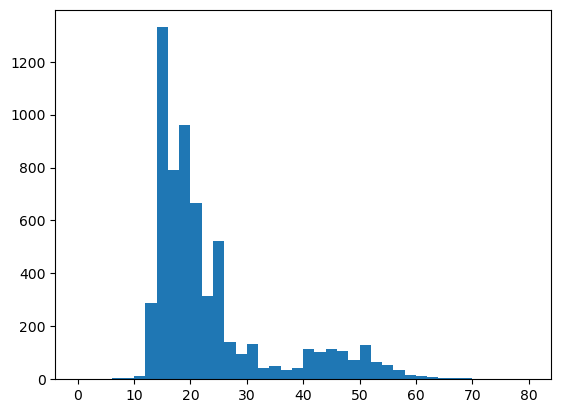

In [15]:
plt.hist(fileCounts, bins=40, range=(0,80))

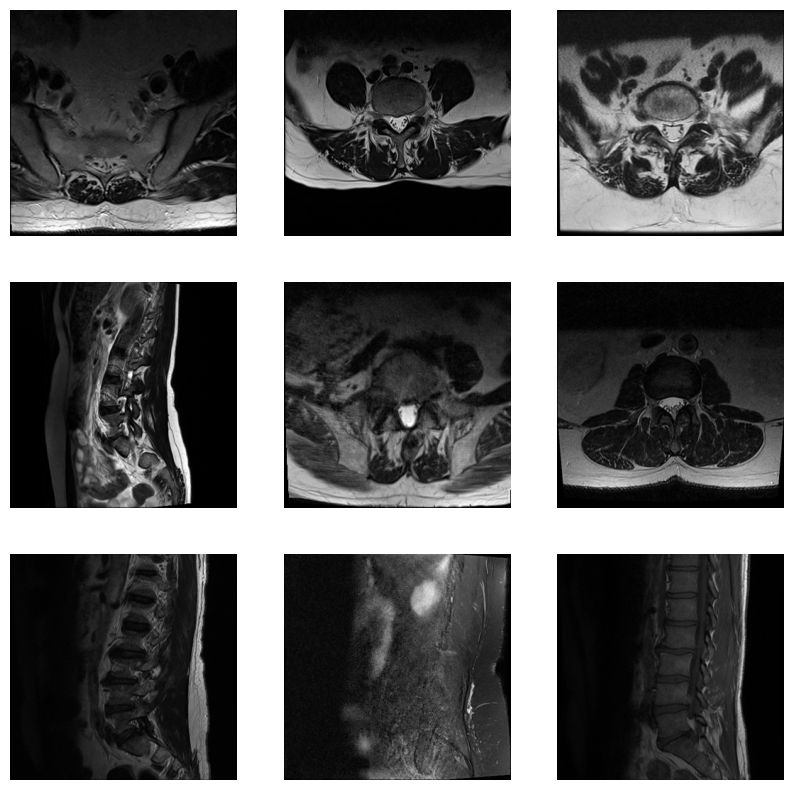

In [16]:
IMG_SIZE = (320, 320)


from utils import dicomToArray


# plt.figure(figsize=(10,10))
# _ = plt.imshow(dicomToArray(os.path.join(DATA_PATH, "train_images/3188843711/1039315139\\6.dcm"), IMG_SIZE), cmap="gray")
# _ = plt.colorbar()

plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(dicomToArray(filePath, IMG_SIZE), cmap="gray")
    _ = plt.axis("off")
# plt.colorbar()

## Dataset

In [17]:
TRAIN_TEST_SPLIT = 0.7

allStudyIds = np.unique(df.index)
print(allStudyIds)

np.random.seed(5880)
np.random.shuffle(allStudyIds)
print(allStudyIds)

split = int(len(allStudyIds)*TRAIN_TEST_SPLIT)
print("# Training samples:",split)

trainStudyIds = allStudyIds[0:split]
valStudyIds = allStudyIds[split:]


[   4003253    4646740    7143189 ... 4284048608 4287160193 4290709089]
[3587842489  247968996 3336194522 ... 4279833491 3168755174 1722603252]
# Training samples: 1382


In [18]:
import glob
import re

imCount=10 #per seriesType


if os.path.exists(os.path.join(DATA_PATH,"./sampledData.pkl")):
    with open(os.path.join(DATA_PATH,"./sampledData.pkl"), "rb") as f:
        dictData = pickle.load(f)
        XTrain, yTrain, XVal, yVal = dictData["XTrain"], dictData["yTrain"],dictData["XVal"],dictData["yVal"]
else:
    XTrain = []
    yTrain = []
    XVal = []
    yVal = []
    for studyId in tqdm(allStudyIds, smoothing=0.05):
        imData = np.zeros((imCount*uniqueSeriesDescr.shape[0], *IMG_SIZE), dtype=np.uint8)
        labelVecs = []
        for typeIdx, studyType in enumerate(uniqueSeriesDescr):
            try:
                seriesId = dfDescr.loc[(studyId, studyType)]["series_id"].to_numpy()
            except KeyError:
                print(f"Not all relevant series types are present for {studyId=} ... skipping")
                continue
            seriesId = seriesId[0]

            allFilesInDir = glob.glob(os.path.join(DATA_PATH, f"train_images/{studyId}/{seriesId}/*.dcm"))
            #Sort by filename number
            allFilesInDir = sorted(allFilesInDir, key=lambda x:int(re.findall(r"\d+\.dcm", x)[0].replace(".dcm", "")))
            mult = len(allFilesInDir)/imCount

            if mult <= 1:
                for idx, _ in enumerate(allFilesInDir):
                    instance = idx
                    f = allFilesInDir[instance]
                    imData[typeIdx*imCount + idx] = dicomToArray(f, IMG_SIZE)
                    instanceNr = int(re.findall(r"\d+\.dcm", f)[0].replace(".dcm", ""))
                    labelVecs.append(getLabelVector(studyId, seriesId, instanceNr))
            elif mult > 1 and mult < 2.5:
                diff = len(allFilesInDir) - imCount
                for idx in range(10):
                    instance = diff//2+idx
                    f = allFilesInDir[instance]
                    imData[typeIdx*imCount + idx] = dicomToArray(f, IMG_SIZE)
                    instanceNr = int(re.findall(r"\d+\.dcm", f)[0].replace(".dcm", ""))
                    labelVecs.append(getLabelVector(studyId, seriesId, instanceNr))
            elif mult >= 2.5:
                stepsSize = np.floor(mult)-1
                stepCount = stepsSize*imCount
                diff = len(allFilesInDir) - stepCount
                for idx in range(10):
                    instance = int(diff//2+idx*stepsSize)
                    f = allFilesInDir[instance]
                    imData[typeIdx*imCount + idx] = dicomToArray(f, IMG_SIZE)
                    instanceNr = int(re.findall(r"\d+\.dcm", f)[0].replace(".dcm", ""))
                    labelVecs.append(getLabelVector(studyId, seriesId, instanceNr))
            
            if studyId in valStudyIds:
                XVal.append(imData)
                yVal.append(np.max(np.array(labelVecs), axis=0))
            elif studyId in trainStudyIds:
                XTrain.append(imData)
                yTrain.append(np.max(np.array(labelVecs), axis=0))
            else:
                raise Exception("Wrong studyId")
            
    with open(os.path.join(DATA_PATH,"./sampledData.pkl"), "wb") as f:
        pickle.dump({"XTrain":XTrain, "yTrain":yTrain, "XVal":XVal, "yVal": yVal}, f)

assert len(XTrain)==len(yTrain)
assert len(XVal)==len(yVal)
print(XTrain[0].shape)
print(np.min(XTrain[0][0,:,:]), np.max(XTrain[0][0,:,:]))
print(yTrain[0])
print(len(XTrain))


(30, 320, 320)
0 254
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
4144


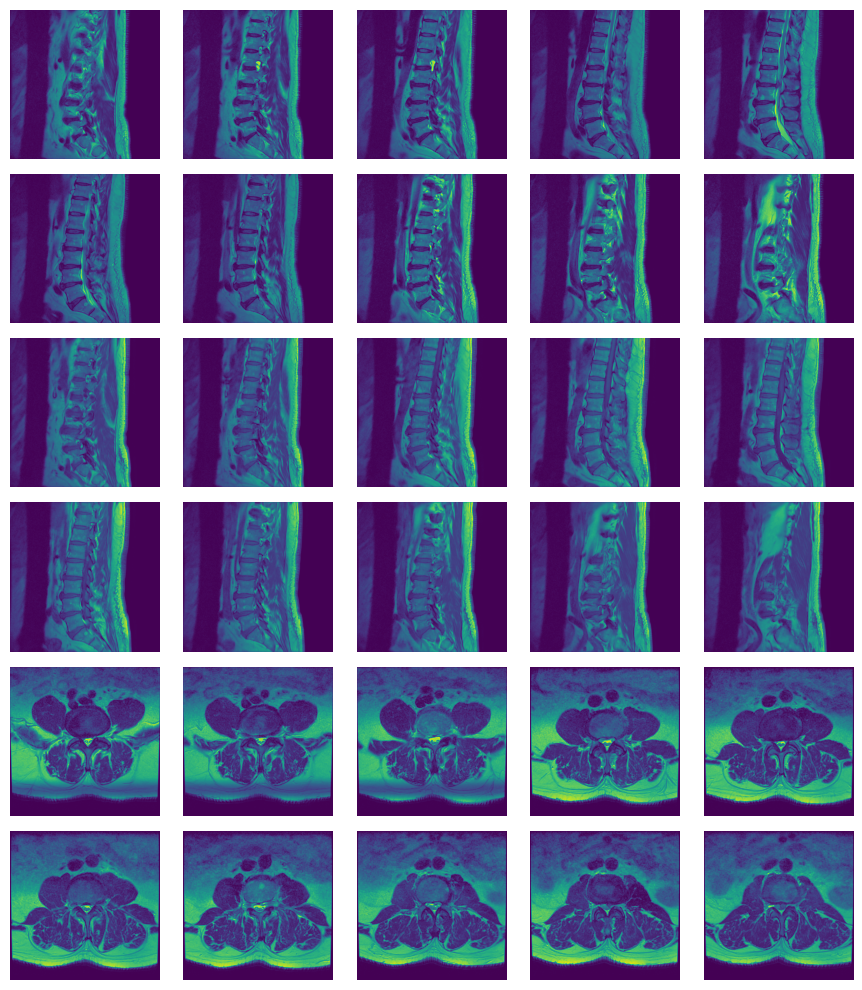

In [19]:
def plotAll(imArr):
    plt.figure(figsize=(9,10))
    for i in range(30):
        plt.subplot(6,5,i+1)
        plt.imshow(imArr[i,:,:])
        plt.axis("off")
        plt.tight_layout()

plotAll(XTrain[2])

In [20]:
import albumentations as A

augProb = 0.75

transforms = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), p=augProb),
    A.OneOf([
        A.MotionBlur(blur_limit=5),
        A.MedianBlur(blur_limit=5),
        A.GaussianBlur(blur_limit=5),
        A.GaussNoise(var_limit=(0.005, 0.1)),
    ], p=augProb),

    A.OneOf([
        A.OpticalDistortion(distort_limit=1.0),
        A.GridDistortion(num_steps=5, distort_limit=0.6),
        A.ElasticTransform(alpha=3),
    ], p=augProb),

    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, border_mode=0, p=augProb),
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.CoarseDropout(max_holes=16, max_height=32, max_width=32, min_holes=1, min_height=8, min_width=8, p=augProb),    
    A.Normalize(max_pixel_value=1.0)
])

transformsVal = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(max_pixel_value=1.0)
])

import random
random.seed(5584)
trainData = list(zip(XTrain,yTrain))
random.shuffle(trainData)
valData = list(zip(XVal,yVal))
random.shuffle(valData)


# trainData = trainData[0:300]
# valData = valData[0:300]

def generator():
    for im, label in trainData:
        im = im.astype(np.float32)
        for imIdx in range(imCount*uniqueSeriesDescr.shape[0]):
            im[imIdx] = im[imIdx]/255.0
            im[imIdx] = transforms(image=im[imIdx])["image"]
        im = torch.Tensor(im)
        yield im, np.array(label).astype(np.int64)


def generatorVal():
    for imVal, labelVal in valData:
        imVal = imVal.astype(np.float32)
        for imIdxVal in range(imCount*uniqueSeriesDescr.shape[0]):
            imVal[imIdxVal] = imVal[imIdxVal]/255.0
            imVal[imIdxVal] = transformsVal(image=imVal[imIdxVal])["image"]
        imVal= torch.Tensor(imVal)
        yield imVal, np.array(labelVal).astype(np.int64)

g = generator()
gVal = generatorVal()
testInstance = next(g)
testInstanceVal = next(gVal)

c:\Users\Manuel\anaconda3\envs\ml\Lib\site-packages\pydantic\main.py:176: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  self.__pydantic_validator__.validate_python(data, self_instance=self)


tensor(-2.1179) tensor(2.2489)
torch.Size([30, 320, 320])
[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
['spinal_canal_stenosis_l3_l4']


<Figure size 800x800 with 0 Axes>

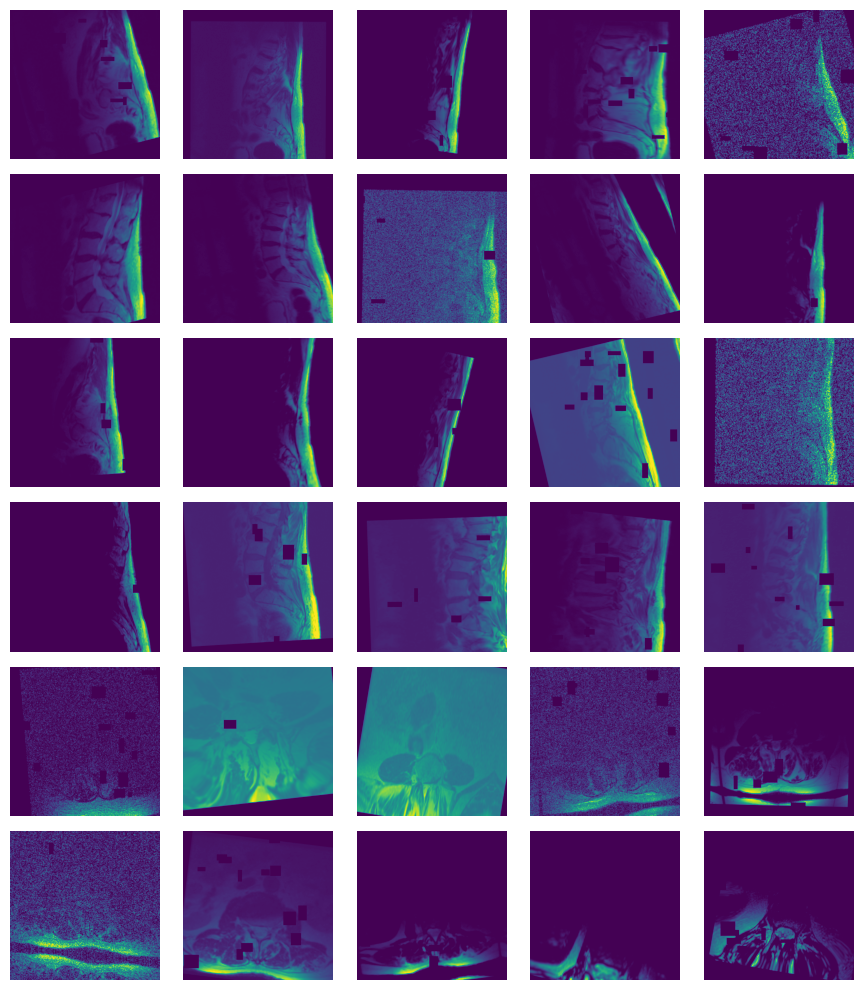

In [21]:
testInstance = next(g)
testInstanceVal = next(gVal)

plt.figure(figsize=(8,8))
plotAll(testInstance[0].numpy())
print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])
print(allLabels[testInstance[1]>0])

In [22]:
BATCH_SIZE = 32

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(trainData))
datasetVal = IterDataset(generatorVal, len(valData))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [23]:
for XData, targets in trainLoader:
    print(f"Shape of X: {XData.shape} {XData.dtype}")
    print("Max and Min: ", torch.max(XData), torch.min(XData))
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    break

Shape of X: torch.Size([32, 30, 320, 320]) torch.float32
Max and Min:  tensor(2.2489) tensor(-2.1179)
Shape of target: torch.Size([32, 25]) torch.int64


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0])


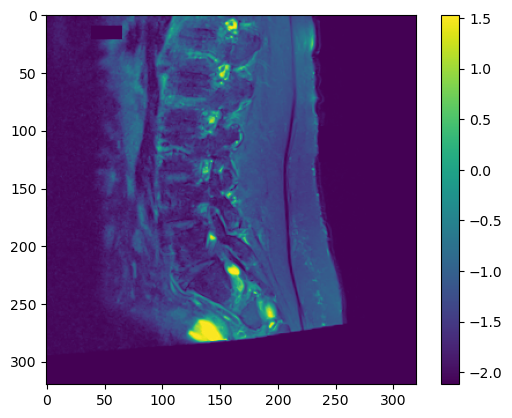

In [24]:
idx=4
print(targets[idx])
# plt.figure(figsize=(12,12))
plt.imshow(XData[idx,1,:,:])
plt.colorbar()
# _=plt.axis("off")

In [25]:
del XData, targets, testInstance, testInstanceVal

## Model

In [26]:
from utils import FocalLoss

# 8 Instances and 3 classes (0,1,2)
targetsTest = torch.Tensor([[0,2,0,1,0,2,0,1]]).type(torch.LongTensor) 
predsTest = torch.randn((1,3,8)).type(torch.float64)
print(predsTest)
focalloss = FocalLoss()
focalloss(predsTest, targetsTest)

tensor([[[-0.5339, -0.5146,  1.4245,  0.1343, -0.3935,  1.0729,  0.2794,
           2.1219],
         [-0.9447, -1.0088, -0.7492,  0.8337, -1.3589, -0.1093,  0.4552,
           0.5457],
         [-1.3358,  2.0716, -0.4508, -0.8407, -1.6062,  1.2904, -0.8704,
          -0.9970]]], dtype=torch.float64)


tensor(0.2165, dtype=torch.float64)

In [27]:
import torchinfo


use_amp = True


class Classifier(torch.nn.Module):
    def __init__(self, backbone):
        super(Classifier, self).__init__()
        self.basemodel = timm.create_model(backbone, pretrained=True, num_classes=len(allLabels)*len(labelMapping), in_chans=imCount*uniqueSeriesDescr.shape[0])
        self.name=f"DepthClassifier_{backbone}"

    def forward(self, x):
        x = self.basemodel(x)
        x = torch.reshape(x, (x.shape[0], len(labelMapping), len(allLabels)))
        return x


model = Classifier("resnet18d")

# from torchview import draw_graph

# model_graph = draw_graph(model, input_size=(BATCH_SIZE,1,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)
model = model.to(device)


with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
    print(torchinfo.summary(model, input_size=[BATCH_SIZE,imCount*uniqueSeriesDescr.shape[0],IMG_SIZE[0],IMG_SIZE[1]], depth=3))

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/resnet18d.ra2_in1k)
INFO:timm.models._hub:[timm/resnet18d.ra2_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:timm.models._builder:Converted input conv conv1.0 pretrained weights from 3 to 30 channel(s)
INFO:timm.models._builder:Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


Layer (type:depth-idx)                        Output Shape              Param #
Classifier                                    [32, 3, 25]               --
├─ResNet: 1-1                                 [32, 75]                  --
│    └─Sequential: 2-1                        [32, 64, 160, 160]        --
│    │    └─Conv2d: 3-1                       [32, 32, 160, 160]        8,640
│    │    └─BatchNorm2d: 3-2                  [32, 32, 160, 160]        64
│    │    └─ReLU: 3-3                         [32, 32, 160, 160]        --
│    │    └─Conv2d: 3-4                       [32, 32, 160, 160]        9,216
│    │    └─BatchNorm2d: 3-5                  [32, 32, 160, 160]        64
│    │    └─ReLU: 3-6                         [32, 32, 160, 160]        --
│    │    └─Conv2d: 3-7                       [32, 64, 160, 160]        18,432
│    └─BatchNorm2d: 2-2                       [32, 64, 160, 160]        128
│    └─ReLU: 2-3                              [32, 64, 160, 160]        --
│    └─Ma

In [28]:
loadExistingModel=False

if loadExistingModel:
    model = model.to(device)
    checkpoint = torch.load(os.path.join("./", "edgenextBase_384_epoch_8.pt"), map_location=device)
    print(model.load_state_dict(checkpoint['model_state_dict']))
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, steps_per_epoch=len(trainLoader), epochs=10)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.01)/100))
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    startEpoch = checkpoint['epoch']
    # startEpoch=0
    # loss = checkpoint['loss']
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(trainLoader), epochs=15)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.1)/500))

Epoch 1
-------------------------------
loss: 0.462291, Acc: 0.2855, F1: 0.2494  [   32/ 4144]
loss: 0.272325, Acc: 0.3361, F1: 0.3232  [  160/ 4144]
loss: 0.399948, Acc: 0.3477, F1: 0.3411  [  288/ 4144]
loss: 0.209266, Acc: 0.3525, F1: 0.3476  [  416/ 4144]
loss: 0.255752, Acc: 0.3560, F1: 0.3515  [  544/ 4144]
loss: 0.228390, Acc: 0.3588, F1: 0.3564  [  672/ 4144]
loss: 0.437829, Acc: 0.3687, F1: 0.3664  [  800/ 4144]
loss: 0.329644, Acc: 0.3790, F1: 0.3779  [  928/ 4144]
loss: 0.236526, Acc: 0.3840, F1: 0.3831  [ 1056/ 4144]
loss: 0.310529, Acc: 0.3846, F1: 0.3846  [ 1184/ 4144]
loss: 0.298226, Acc: 0.3829, F1: 0.3838  [ 1312/ 4144]
loss: 0.203454, Acc: 0.3834, F1: 0.3850  [ 1440/ 4144]
loss: 0.290184, Acc: 0.3825, F1: 0.3851  [ 1568/ 4144]
loss: 0.204734, Acc: 0.3825, F1: 0.3855  [ 1696/ 4144]
loss: 0.281448, Acc: 0.3845, F1: 0.3878  [ 1824/ 4144]
loss: 0.376268, Acc: 0.3871, F1: 0.3903  [ 1952/ 4144]
loss: 0.263688, Acc: 0.3888, F1: 0.3919  [ 2080/ 4144]
loss: 0.314003, Acc: 0.39

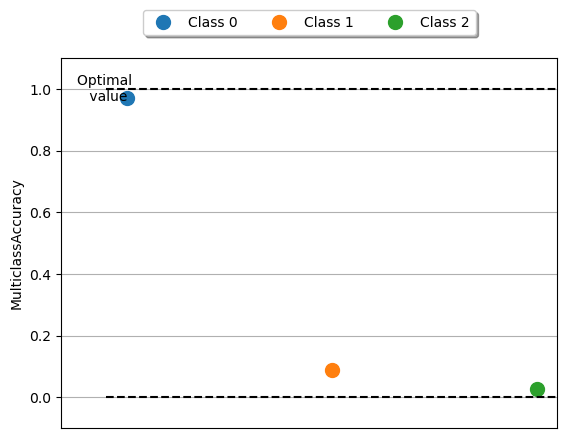

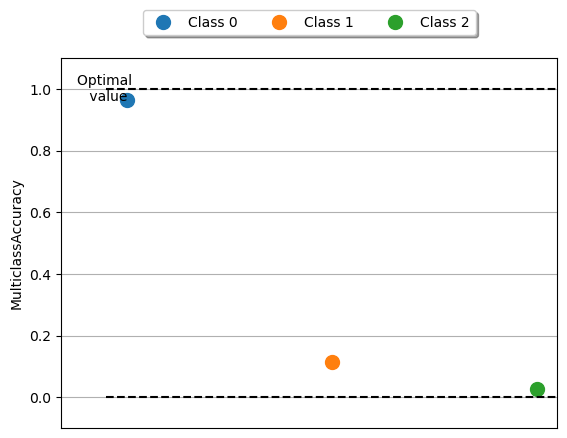

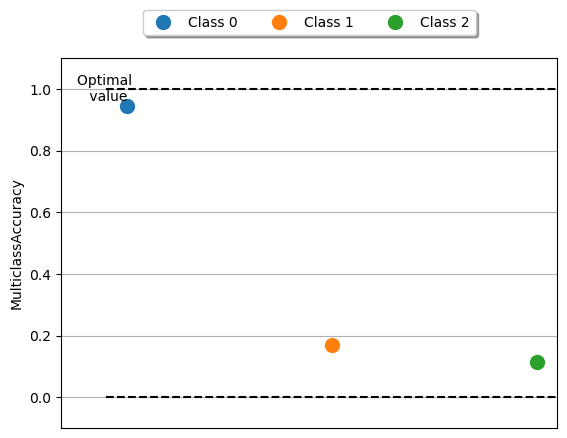

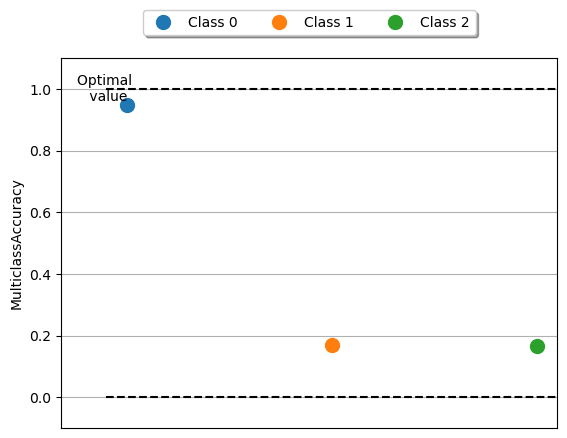

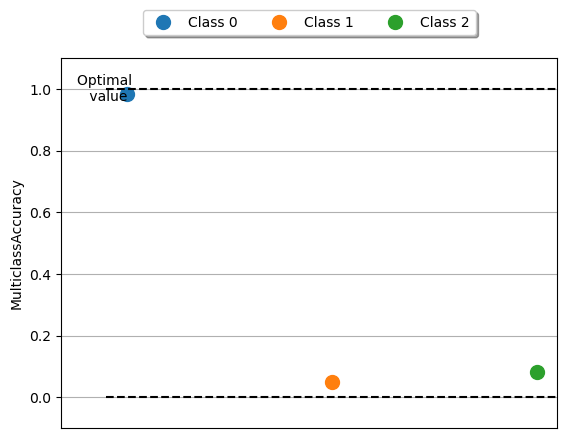

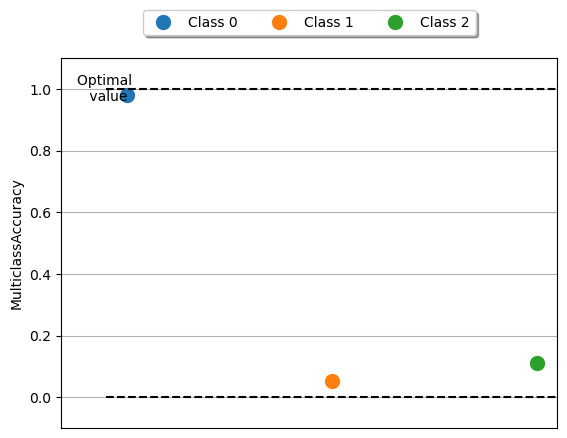

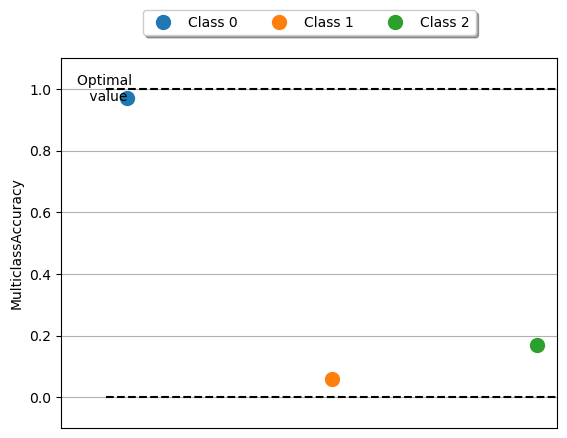

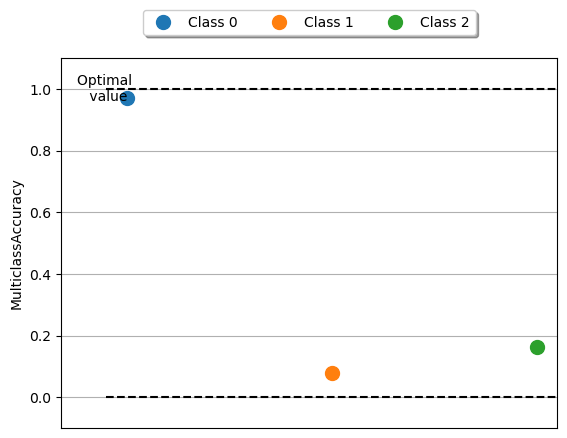

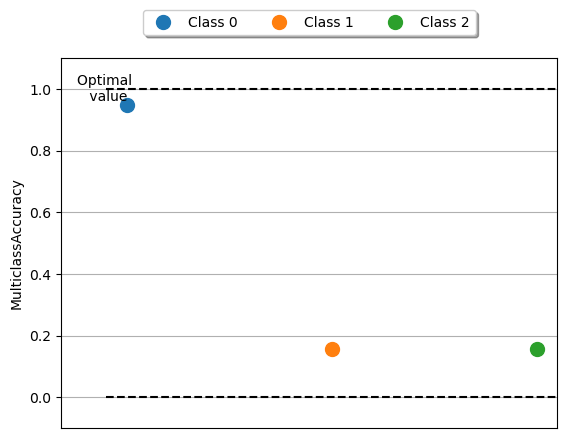

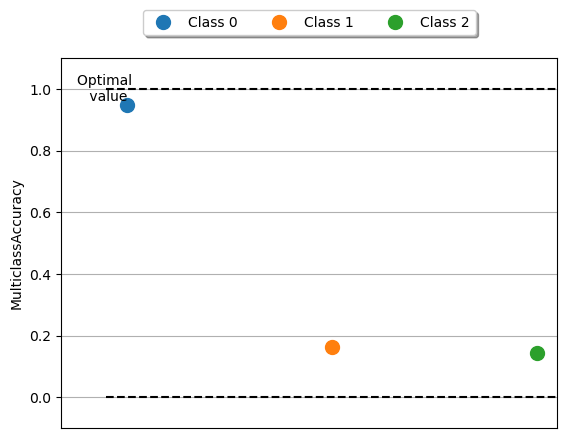

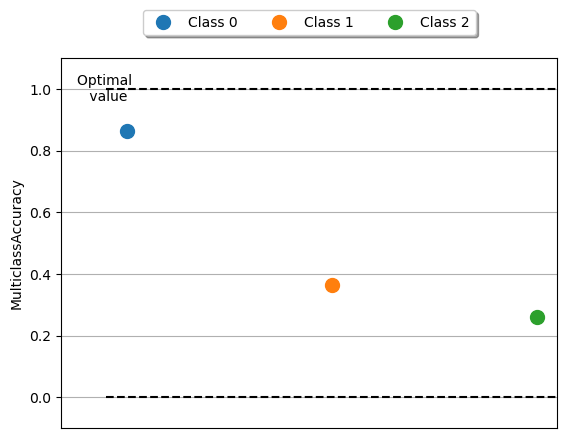

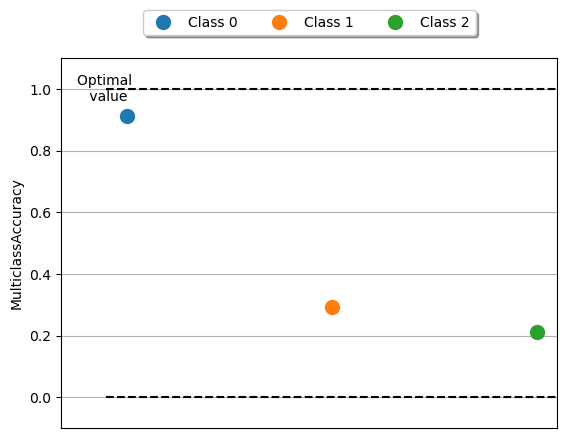

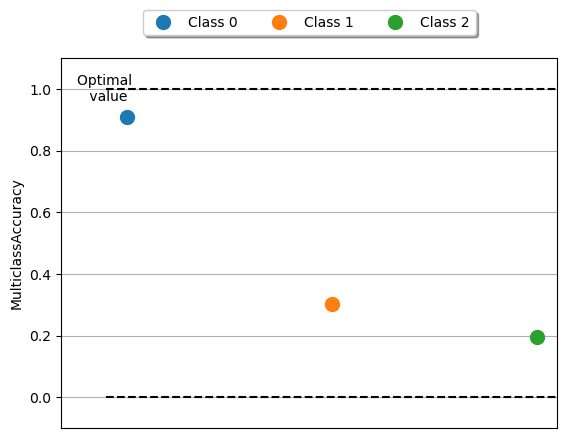

In [29]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

LOG_INTERVAL=4
epochs = 100
saveModel=False
SAVE_MODEL_INTERVAL=10
EARLY_STOPPING_PATIENCE = 2



scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

log_dir = "./logs/"+model.name+"/" + datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = SummaryWriter(log_dir)


# Instantiate a loss function.
weights = torch.tensor([1.0, 2.0, 4.0]).to(device)
loss = FocalLoss(weights=weights)
# loss = torch.nn.CrossEntropyLoss(weight=weights)
# lossVal = FocalLoss(weights=weights)
lossVal = torch.nn.CrossEntropyLoss(weight=weights)

f1Metric = MulticlassF1Score(num_classes=len(labelMapping)).to(device)
accMetric = MulticlassAccuracy(num_classes=len(labelMapping)).to(device)

f1MetricVal = MulticlassF1Score(num_classes=len(labelMapping)).to(device)
accMetricVal = MulticlassAccuracy(num_classes=len(labelMapping), average=None).to(device)


def train(dataloader, model, lossFn, optimizer, epoch):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            # Compute prediction error
            pred = model(X)
            loss = lossFn(pred, y)
        accMetric.update(pred, y)
        f1Metric.update(pred, y)

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        if batch % LOG_INTERVAL == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}, Acc: {accMetric.compute():.4f}, F1: {f1Metric.compute():.4f}  [{current:>5d}/{size:>5d}]")
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Accuracy", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("F1", f1Metric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()

@torch.no_grad()
def validate(dataloader, model, loss_fn, epoch):
    num_batches = len(dataloader)
    model.eval()
    valLoss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            valLoss += loss_fn(pred, y).item()
            accMetricVal.update(pred, y)
            f1MetricVal.update(pred, y)

    valLoss /= num_batches
    fig_, ax_ = accMetricVal.plot()
    fig_.savefig(f"./valPlots/acc_{t}.png")
    
    print(f"Validation: Loss {valLoss:>4f}, F1 {f1MetricVal.compute():.4f}  Accuracy {torch.mean(accMetricVal.compute()):.4f} \n")
    summary_writer.add_scalar("Val Loss", valLoss, epoch)
    summary_writer.add_scalar("Val Accuracy", torch.mean(accMetricVal.compute()), epoch)
    summary_writer.add_scalar("Val F1", f1MetricVal.compute(), epoch)
    summary_writer.flush()
    return valLoss

bestPerformance=99
bestEpoch=0

for t in np.arange(startEpoch, startEpoch + epochs, 1):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainLoader, model, loss, optimizer, t)
    valLoss=validate(valLoader, model, lossVal, t)
    # scheduler.step()
    if t%SAVE_MODEL_INTERVAL==0:
        print("LR: ", optimizer.param_groups[0]['lr'])
    if valLoss < bestPerformance:
        bestPerformance = valLoss
        print(f"New best performance: {bestPerformance:.4f}")
        bestF1=f1MetricVal.compute()
        bestEpoch=t
        bestWeights = model.state_dict()
    if t-bestEpoch>EARLY_STOPPING_PATIENCE:
        print(f"Early Stopping. {bestF1=}")
        break
    accMetric.reset()
    f1Metric.reset()
    accMetricVal.reset()
    f1MetricVal.reset()

print("Done!")

In [30]:
print(model.load_state_dict(bestWeights))

torch.save({
        'epoch': t,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # "scaler": scaler.state_dict(),
        # 'scheduler_state_dict': scheduler.state_dict(),
        # 'loss': loss,
        }, os.path.join("./", f"{model.name}_{IMG_SIZE[0]}_F1_{bestF1:.3f}_CE_{bestPerformance:.3f}_epoch_{bestEpoch}.pt"))

<All keys matched successfully>
